# PLANIFICADORES

OBJETIVO: Obtener el minimo local
Ajustamos el learning rate para llegar cuanto antes:
    - Muy grande -> nos pasamos
    - Muy pequeño -> no llegamos nunca
Podemos utilizar Planificadores (= condiciones que se verifican en la ejecución) para poder ajustar mejor



EXAMEN: "ultima parte y esta"

## Introducción

Heredan de una clase base. 
# Parámetros:
#   - optimizer: optimizador cuyo learning rate se ajusta
#   - last_epoch: indice de la ultima epcoa vista por el planificador

Hay distintos tipos de schedulers. Uno es el StepLR, que cambia el learning rate cada X epocas

In [1]:
import numpy as np; import matplotlib.pyplot as plt
import torch; import torch.optim as optim; import torch.nn as nn

In [2]:
def get_lrs(optimizer, scheduler, steps=100, val_loss=None):
    lrs = []
    for t in range(steps):
        lrs += scheduler.get_last_lr(); optimizer.step()
        if val_loss == None: scheduler.step()
        else: scheduler.step(val_loss[t])
    return lrs

[(-0.1, 10.1),

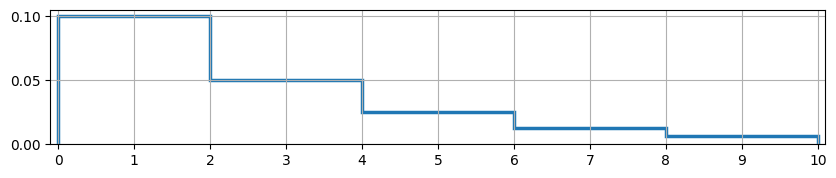

In [3]:
# Definimos un modelo. Para cada epoca PAR, se reduce el learning rate a la mitadP
model = nn.Linear(10, 2)
optimizer = optim.SGD(model.parameters(), lr=0.1)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
steps = 10
lrs = get_lrs(optimizer, scheduler, steps=steps)
_, ax = plt.subplots(figsize=(10, 1.75))
ax.stairs(lrs, linewidth=2.5)
ax.grid()
ax.set(xlim=(-0.1, steps + 0.1), xticks=np.arange(0, steps + 1))

ReduceLROnPlateau
# Parametros
#   patience, threshold(mejora minima que consideramos valida) -> permiten establecer una mejora esperada que, en caso de no cumplirse en X epocas, reducimos el learning rate
#   mode = 'min' -> Buscamos minimizar el parametro; 'max' -> Buscamos maximizar el parametro

[(-0.1, 30.1),

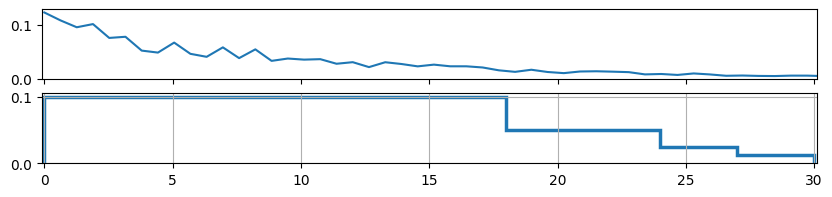

In [ ]:
model = nn.Linear(10, 2)
optimizer = optim.SGD(model.parameters(), lr=0.1)
steps = 30
x = np.linspace(0, steps + 1)
exp_lambda = 0.1
val_loss = torch.from_numpy(exp_lambda * np.exp(-exp_lambda * x))
val_loss += (
    val_loss
    * (
        torch.rand_like(
            val_loss,
        )
        - 0.5
    )
    * 0.5
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)
lrs = get_lrs(optimizer, scheduler, steps=steps, val_loss=val_loss)
_, (ax_loss, ax) = plt.subplots(2, figsize=(10, 2), sharex=True)
ax_loss.plot(x, val_loss)
ax.stairs(lrs, linewidth=2.5)
ax.grid()
ax.set(xlim=(-0.1, steps + 0.1), xticks=np.arange(0, steps + 1, 5))


# Seguimos la funcion de perdida. Cuando hay una llanura, reducimos para poder reducir más
# Cuando realizamos un experimento preliminar, utilizamos este 

CosineAnnealing: aplica una funcion coseno
# Parametros
#   T-max = numero max de pasos
#   eta_min = learning rate minimo

[(-0.1, 50.1),

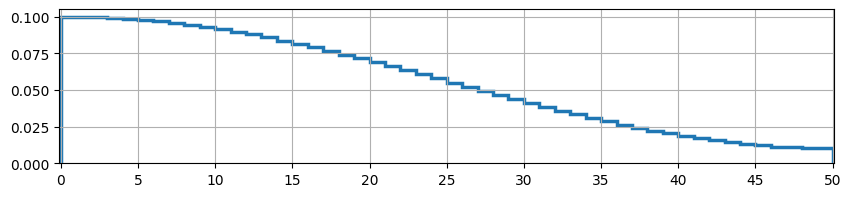

In [5]:
model = nn.Linear(10, 2)
optimizer = optim.SGD(model.parameters(), lr=0.1)
steps = 50
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, steps, eta_min=0.010)
lrs = get_lrs(optimizer, scheduler, steps=steps)
_, ax = plt.subplots(figsize=(10, 2))
ax.stairs(lrs, linewidth=2.5)
ax.grid()
ax.set(xlim=(-0.1, steps + 0.1), xticks=np.arange(0, steps + 1, 5))

Warmup: scheduler donde al principio aumentamos el learning rate (no se utilizan tanto)
# Parametros:
#   t_initial= nimero total de epocas/pasos
#   warmup_t = pasos de warmup inicial

[(-0.1, 50.1),

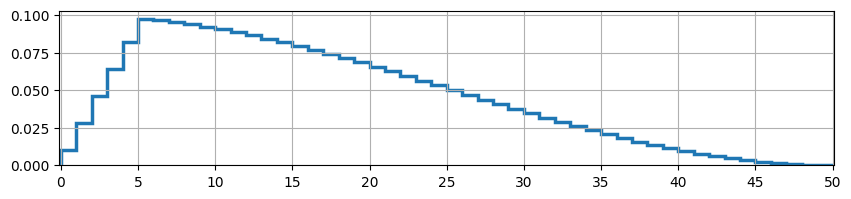

In [8]:
from timm.scheduler.cosine_lr import CosineLRScheduler

model = nn.Linear(10, 2)
optimizer = optim.SGD(model.parameters(), lr=0.1)
steps = 50
scheduler = CosineLRScheduler(
    optimizer, t_initial=steps, warmup_t=5, warmup_lr_init=1e-2
)
lrs = [scheduler._get_lr(t)[0] for t in range(steps)]
_, ax = plt.subplots(figsize=(10, 2))
ax.stairs(lrs, linewidth=2.5)
ax.grid()
ax.set(xlim=(-0.1, steps + 0.1), xticks=np.arange(0, steps + 1, 5))

Warmup-Stable-Decay: 

[(-0.1, 50.1),

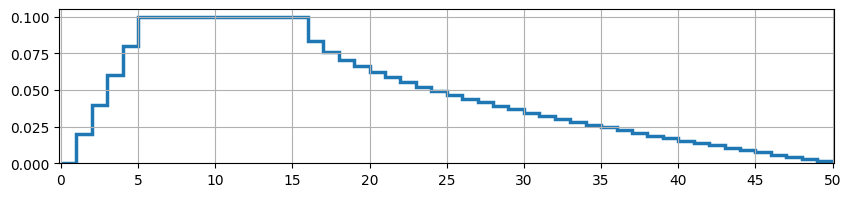

In [11]:
from pytorch_optimizer import get_wsd_schedule

model = nn.Linear(10, 2)
optimizer = optim.SGD(model.parameters(), lr=0.1)
steps = 50
scheduler = get_wsd_schedule(optimizer, 5, 10, 35)
lrs = get_lrs(optimizer, scheduler, steps=steps)
_, ax = plt.subplots(figsize=(10, 2))
ax.stairs(lrs, linewidth=2.5)
ax.grid()
ax.set(xlim=(-0.1, steps + 0.1), xticks=np.arange(0, steps + 1, 5))

# Ejemplo

In [14]:
def exp(model, device, train_loader, test_loader, optimizer, scheduler, epochs=15):
    loss_fn = torch.nn.CrossEntropyLoss()
    for epoch in range(epochs):
        print(f'Epoch {epoch}: train:', end=' ')
        model.train(); trsize, trbatches, trloss, tracc = 0, 0, 0, 0
        for batch in train_loader:
            X, y = batch['X'].to(device), batch['y'].to(device); trsize += len(X); trbatches += 1
            pred = model(X); loss = loss_fn(pred, y); trloss += loss.item()
            tracc += (pred.argmax(1) == y).type(torch.float).sum().item()
            loss.backward(); optimizer.step(); optimizer.zero_grad(); scheduler.step()
        trloss /= trbatches; tracc /= trsize
        print(f'loss {trloss:g} acc {tracc:.2%} test:', end=' ')
        model.eval(); tesize, tebatches, teloss, teacc = 0, 0, 0, 0
        with torch.no_grad():
            for batch in test_loader:
                X, y = batch['X'].to(device), batch['y'].to(device); tesize += len(X); tebatches += 1
                pred = model(X); teloss += loss_fn(pred, y).item()
                teacc += (pred.argmax(1) == y).type(torch.float).sum().item()
        teloss /= tebatches; teacc /= tesize
        print(f'loss {teloss:g} acc {teacc:.2%}')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import timm


device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
device
model_name = "resnet50.fb_swsl_ig1b_ft_in1k"  # avg_top1 71.5 param_count 25.56
model = timm.create_model(model_name, pretrained=True, num_classes=10).to(device)

In [17]:
# Va reduciendo el learningn rate siguiendo una funcion de coseno
# En ingun momento se nos estanca el modelo.

import datasets
from torch.utils.data import DataLoader

ds = (
    datasets.load_dataset("uoft-cs/cifar10")
    .with_format("torch")
    .rename_columns({"img": "X", "label": "y"})
)


def datanorm(example):
    example["X"] = example["X"].to(torch.float) / 255.0
    return example


ds = ds.map(datanorm, batched=True)
train_ds = ds["train"].to_iterable_dataset(num_shards=1024)
test_ds = ds["test"].to_iterable_dataset(num_shards=1024)
train_loader = DataLoader(train_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
)
steps = 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, steps, eta_min=1e-5)
exp(model, device, train_loader, test_loader, optimizer, scheduler, epochs=steps)

KeyboardInterrupt: 

In [ ]:
# MNIST
import numpy as np
import matplotlib.pyplot as plt
import torch
import timm

device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
device
model_name = "resnet50.fb_swsl_ig1b_ft_in1k"  # avg_top1 71.5 param_count 25.56
model = timm.create_model(model_name, pretrained=True, num_classes=10, in_chans=1).to(
    device
)

In [ ]:
import datasets
from torch.utils.data import DataLoader

ds = (
    datasets.load_dataset("ylecun/mnist")
    .with_format("torch")
    .rename_columns({"image": "X", "label": "y"})
)


def datanorm(example):
    example["X"] = example["X"].to(torch.float) / 255.0
    return example


ds = ds.map(datanorm, batched=True)
train_ds = ds["train"].to_iterable_dataset(num_shards=1024)
test_ds = ds["test"].to_iterable_dataset(num_shards=1024)
train_loader = DataLoader(train_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)
# Definimos el optimizador
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
)
steps = 20
# Definimos el scheduler que irá modificando el learning rate: CosineAnnealing
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, steps, eta_min=1e-5)
exp(model, device, train_loader, test_loader, optimizer, scheduler, epochs=steps)

In [ ]:
# Fashion MNIST
device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
device
model_name = "resnet50.fb_swsl_ig1b_ft_in1k"  # avg_top1 71.5 param_count 25.56
model = timm.create_model(model_name, pretrained=True, num_classes=10, in_chans=1).to(
    device
)

In [ ]:
import datasets
from torch.utils.data import DataLoader

ds = (
    datasets.load_dataset("zalando-datasets/fashion_mnist")
    .with_format("torch")
    .rename_columns({"img": "X", "label": "y"})
)


def datanorm(example):
    example["X"] = example["X"].to(torch.float) / 255.0
    return example


ds = ds.map(datanorm, batched=True)
train_ds = ds["train"].to_iterable_dataset(num_shards=1024)
test_ds = ds["test"].to_iterable_dataset(num_shards=1024)
train_loader = DataLoader(train_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
)
steps = 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, steps, eta_min=1e-5)
exp(model, device, train_loader, test_loader, optimizer, scheduler, epochs=steps)